#  Generative Adversarial Network (GAN)

Implementar un modelo de GANs (generación de imágenes): usar images de la CNN, caras pequeñas como CelebA,  para entrenar un DCGAN. 

### Objetivo: 
- Entrenar una un modelo usando el dataset CelebA.

### Puntos Clave: 
- Generar una GAN estable usando tecnicas aprendidas.
- Genearar una cuadricula de imagenes generadas para ver como progresan la calidad al avanzar las epocas.
- Realizar una grafica de la perdida del Discriminador vs la perdida del Generador.

In [1]:
# DCGAN para generación de rostros con CelebA

## Objetivo

# Implementar una red generativa adversarial convolucional profunda, o DCGAN, para generar imágenes sintéticas de rostros humanos a partir del dataset CelebA.

## Entregables del módulo GAN

# 1. Carga y preprocesamiento del dataset CelebA.
# 2. Definición del Generador.
# 3. Definición del Discriminador.
# 4. Definición de funciones de pérdida.
# 5. Implementación del paso de entrenamiento con `GradientTape`.
# 6. Entrenamiento alternado de Generador y Discriminador.
# 7. Guardado de imágenes generadas por época.
# 8. Cuadrícula de evolución visual de imágenes generadas.
# 9. Gráfica de pérdida del Discriminador vs pérdida del Generador.
# 10. Comentario técnico de resultados para reporte o README.

## Descripción técnica breve
# Una GAN está formada por dos redes neuronales que compiten entre sí. El Generador recibe un vector aleatorio `z`
#  del espacio latente y produce una imagen sintética. El Discriminador recibe imágenes reales y generadas, y aprende
#  a distinguirlas. En una DCGAN, ambas redes utilizan capas convolucionales para trabajar directamente con la estructura espacial de las imágenes.

In [2]:
!pip install tensorflow tensorflow-datasets matplotlib pandas numpy pillow imageio

In [3]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

# Reproducibilidad parcial
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Directorios de salida
PROJECT_DIR = Path(".")
RESULTS_DIR = PROJECT_DIR / "results"
IMAGES_DIR = RESULTS_DIR / "generated_images"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
MODELS_DIR = RESULTS_DIR / "models"

for folder in [RESULTS_DIR, IMAGES_DIR, CHECKPOINT_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente.")

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Carpetas creadas correctamente.


In [4]:
# Tamaño de imagen de trabajo
IMG_SIZE = 64
CHANNELS = 3
IMAGE_SHAPE = (IMG_SIZE, IMG_SIZE, CHANNELS)

# Vector latente z
LATENT_DIM = 100

# Entrenamiento
BATCH_SIZE = 64
EPOCHS = 30

# Para pruebas rápidas, podés usar 10000 o 30000 imágenes.
# Para usar todo CelebA, poné MAX_IMAGES = None.
MAX_IMAGES = 30000

# Learning rates
GEN_LR = 2e-4
DISC_LR = 1e-4

# Parámetros Adam recomendados en DCGAN
BETA_1 = 0.5
BETA_2 = 0.999

# Ruido fijo para evaluar la evolución visual en cada época
NUM_EXAMPLES_TO_GENERATE = 16
FIXED_NOISE = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])

print("Configuración cargada.")

Configuración cargada.


In [5]:
def find_local_celeba_dir():
    """
    Busca automáticamente una carpeta que contenga imágenes .jpg de CelebA.
    
    Rutas frecuentes:
    - Kaggle: /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba
    - Local: ./data/celeba/img_align_celeba
    - Local: ./data/img_align_celeba
    """
    candidate_dirs = [
        "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba",
        "/kaggle/input/celeba-dataset/img_align_celeba",
        "./data/celeba/img_align_celeba",
        "./data/img_align_celeba",
        "./celeba/img_align_celeba",
        "./img_align_celeba",
    ]
    
    for d in candidate_dirs:
        path = Path(d)
        if path.exists():
            jpg_files = list(path.glob("*.jpg"))
            if len(jpg_files) > 0:
                return path
    
    return None


def preprocess_image_from_path(path):
    """
    Lee una imagen desde disco, la recorta al centro, la redimensiona
    y la normaliza al rango [-1, 1].
    
    La normalización [-1, 1] se usa porque el Generador terminará con activación tanh.
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.cast(image, tf.float32)
    
    # CelebA alineado suele venir aproximadamente en 218x178.
    # Se recorta/paddea al centro para obtener una región cuadrada.
    image = tf.image.resize_with_crop_or_pad(image, 178, 178)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    # Normalización de [0, 255] a [-1, 1]
    image = (image / 127.5) - 1.0
    return image


def preprocess_image_from_tfds(example):
    """
    Preprocesamiento equivalente para ejemplos cargados desde tensorflow_datasets.
    """
    image = example["image"]
    image = tf.cast(image, tf.float32)
    image = tf.image.resize_with_crop_or_pad(image, 178, 178)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = (image / 127.5) - 1.0
    return image


celeba_dir = find_local_celeba_dir()

if celeba_dir is not None:
    print(f"Dataset local encontrado en: {celeba_dir}")
    
    image_paths = tf.data.Dataset.list_files(
        str(celeba_dir / "*.jpg"),
        shuffle=True,
        seed=SEED
    )
    
    if MAX_IMAGES is not None:
        image_paths = image_paths.take(MAX_IMAGES)
    
    train_dataset = (
        image_paths
        .map(preprocess_image_from_path, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(10000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )

else:
    print("No se encontró CelebA local. Intentando cargar con tensorflow_datasets...")
    import tensorflow_datasets as tfds
    
    raw_ds = tfds.load(
        "celeb_a",
        split="train",
        shuffle_files=True
    )
    
    if MAX_IMAGES is not None:
        raw_ds = raw_ds.take(MAX_IMAGES)
    
    train_dataset = (
        raw_ds
        .map(preprocess_image_from_tfds, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(10000, seed=SEED)
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )

print("Dataset preparado.")

No se encontró CelebA local. Intentando cargar con tensorflow_datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.HBRPOI_2.1.0/celeb_a-validation.tfrecord-[0-9][0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.HBRPOI_2.1.0/celeb_a-test.tfrecord-[0-9][0-9][0-9][0-9]…

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.
Dataset preparado.


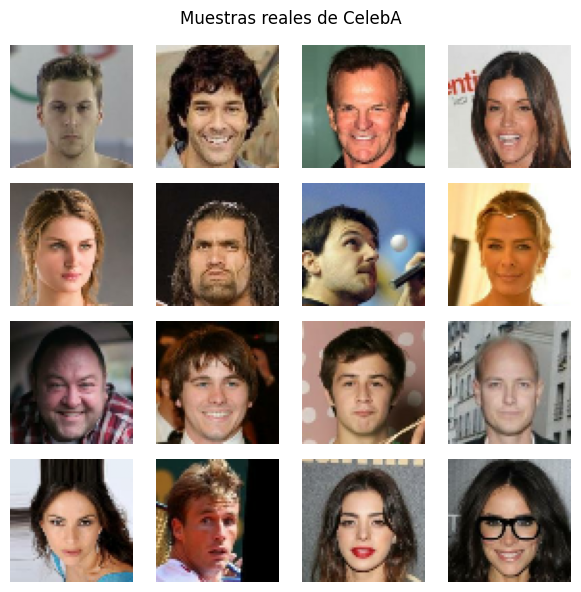

In [6]:
def denormalize_image(image):
    """
    Convierte una imagen del rango [-1, 1] al rango [0, 1]
    para poder visualizarla con matplotlib.
    """
    return (image + 1.0) / 2.0


def show_real_images(dataset, n=16):
    """
    Muestra una cuadrícula de imágenes reales del dataset.
    """
    batch = next(iter(dataset))
    images = batch[:n]
    
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    
    plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(denormalize_image(images[i]).numpy())
        plt.axis("off")
    
    plt.suptitle("Muestras reales de CelebA")
    plt.tight_layout()
    plt.show()


show_real_images(train_dataset, n=16)

## Construccion del generador + Prueba antes de entrenar

In [9]:
def build_generator(latent_dim=LATENT_DIM):
    """
    Generador DCGAN.
    
    Entrada:
    - z: vector latente aleatorio de dimensión LATENT_DIM.
    
    Salida:
    - Imagen RGB de tamaño 64x64x3 en rango [-1, 1].
    """
    initializer = tf.random_normal_initializer(mean=0.0, stddev=0.02)
    
    model = keras.Sequential(name="Generator")
    
    # Proyección inicial: de z a un tensor espacial pequeño 4x4x512
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(4 * 4 * 512, use_bias=False, kernel_initializer=initializer))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((4, 4, 512)))
    
    # 4x4 -> 8x8
    model.add(layers.Conv2DTranspose(
        256, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # 8x8 -> 16x16
    model.add(layers.Conv2DTranspose(
        128, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # 16x16 -> 32x32
    model.add(layers.Conv2DTranspose(
        64, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # 32x32 -> 64x64
    # Salida con tanh porque las imágenes reales están normalizadas a [-1, 1]
    model.add(layers.Conv2DTranspose(
        CHANNELS, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer,
        activation="tanh"
    ))
    
    return model


generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 3)      │         3,072 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,609,344 (13.77 MB)

 Trainable params: 3,592,064 (13.70 MB)

 Non-trainable params: 17,280 (67.50 KB)

### Prueba del generador

Forma de imagen generada: (1, 64, 64, 3)


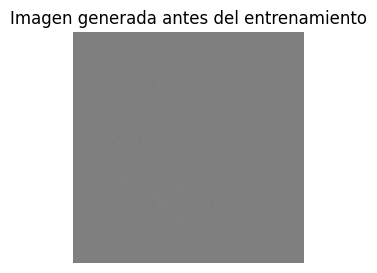

In [10]:
noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)

print("Forma de imagen generada:", generated_image.shape)

plt.figure(figsize=(3, 3))
plt.imshow(denormalize_image(generated_image[0]).numpy())
plt.axis("off")
plt.title("Imagen generada antes del entrenamiento")
plt.show()

## Construccion del discriminador + Prueba antes de entrenar

In [11]:
def build_discriminator(image_shape=IMAGE_SHAPE):
    """
    Discriminador DCGAN.
    
    Entrada:
    - Imagen RGB de tamaño 64x64x3.
    
    Salida:
    - Un logit. Valores altos indican mayor probabilidad de imagen real.
    """
    initializer = tf.random_normal_initializer(mean=0.0, stddev=0.02)
    
    model = keras.Sequential(name="Discriminator")
    
    model.add(layers.Input(shape=image_shape))
    
    # 64x64 -> 32x32
    model.add(layers.Conv2D(
        64, kernel_size=4, strides=2, padding="same",
        kernel_initializer=initializer
    ))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # 32x32 -> 16x16
    model.add(layers.Conv2D(
        128, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # 16x16 -> 8x8
    model.add(layers.Conv2D(
        256, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # 8x8 -> 4x4
    model.add(layers.Conv2D(
        512, kernel_size=4, strides=2, padding="same",
        use_bias=False, kernel_initializer=initializer
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    
    return model


discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,767,425 (10.56 MB)

 Trainable params: 2,765,633 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Prueba del discriminador

In [12]:
decision = discriminator(generated_image, training=False)
print("Logit del discriminador para una imagen falsa inicial:", decision.numpy())

Logit del discriminador para una imagen falsa inicial: [[-5.370477e-05]]


## Funciones de perdida y optimizadores

In [13]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    """
    Pérdida del Discriminador.
    
    real_output: salida del discriminador para imágenes reales.
    fake_output: salida del discriminador para imágenes generadas.
    
    Se aplica label smoothing a las etiquetas reales usando 0.9 en lugar de 1.0.
    Esto reduce la confianza excesiva del discriminador.
    """
    real_labels = tf.ones_like(real_output) * 0.9
    fake_labels = tf.zeros_like(fake_output)
    
    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(fake_labels, fake_output)
    
    total_loss = real_loss + fake_loss
    return total_loss / 2.0


def generator_loss(fake_output):
    """
    Pérdida del Generador.
    
    El generador quiere que las imágenes falsas sean clasificadas como reales.
    Por eso se compara fake_output contra etiquetas 1.
    """
    target_labels = tf.ones_like(fake_output)
    return cross_entropy(target_labels, fake_output)


generator_optimizer = keras.optimizers.Adam(
    learning_rate=GEN_LR,
    beta_1=BETA_1,
    beta_2=BETA_2
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=DISC_LR,
    beta_1=BETA_1,
    beta_2=BETA_2
)

print("Pérdidas y optimizadores definidos.")

Pérdidas y optimizadores definidos.


### Metricas auxiliares

In [14]:
def discriminator_accuracy(real_output, fake_output):
    """
    Calcula una métrica auxiliar de accuracy del discriminador.
    
    Como el discriminador devuelve logits, primero se aplica sigmoid.
    """
    real_probs = tf.sigmoid(real_output)
    fake_probs = tf.sigmoid(fake_output)
    
    real_acc = tf.reduce_mean(tf.cast(real_probs > 0.5, tf.float32))
    fake_acc = tf.reduce_mean(tf.cast(fake_probs < 0.5, tf.float32))
    
    return (real_acc + fake_acc) / 2.0

### Definicion del entrenamiento GradientTape

In [15]:
@tf.function
def train_step(real_images):
    """
    Ejecuta un paso de entrenamiento adversarial:
    
    1. Genera ruido aleatorio z.
    2. El Generador produce imágenes falsas.
    3. El Discriminador evalúa imágenes reales y falsas.
    4. Se calculan pérdidas.
    5. Se actualizan los pesos de ambas redes.
    """
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        
        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)
        
        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)
        d_acc = discriminator_accuracy(real_output, fake_output)
    
    gradients_of_generator = gen_tape.gradient(
        g_loss,
        generator.trainable_variables
    )
    
    gradients_of_discriminator = disc_tape.gradient(
        d_loss,
        discriminator.trainable_variables
    )
    
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )
    
    return d_loss, g_loss, d_acc

### Guardar imagenes generadas por épocas

In [16]:
def generate_and_save_images(model, epoch, test_input, save_dir=IMAGES_DIR):
    """
    Genera una cuadrícula fija de imágenes usando el mismo ruido en cada época.
    
    Esto permite comparar visualmente la evolución del Generador.
    """
    predictions = model(test_input, training=False)
    
    n = predictions.shape[0]
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    
    plt.figure(figsize=(6, 6))
    
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(denormalize_image(predictions[i]).numpy())
        plt.axis("off")
    
    plt.suptitle(f"Imágenes generadas - Época {epoch}")
    plt.tight_layout()
    
    output_path = save_dir / f"epoch_{epoch:03d}.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    
    return output_path

In [17]:
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

checkpoint_manager = tf.train.CheckpointManager(
    checkpoint,
    directory=str(CHECKPOINT_DIR),
    max_to_keep=5
)

print("Sistema de checkpoints preparado.")

Sistema de checkpoints preparado.


## Entrenamiento de los modelos

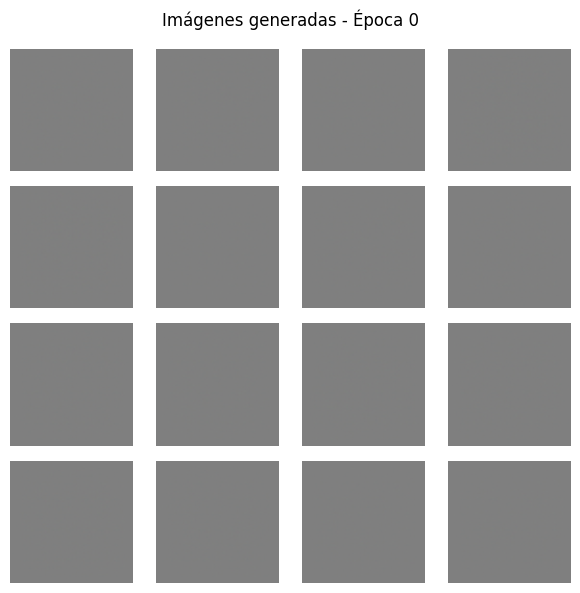

Época 001/30 | D Loss: 0.4198 | G Loss: 2.4407 | D Acc: 0.8666 | Tiempo: 81.9 s


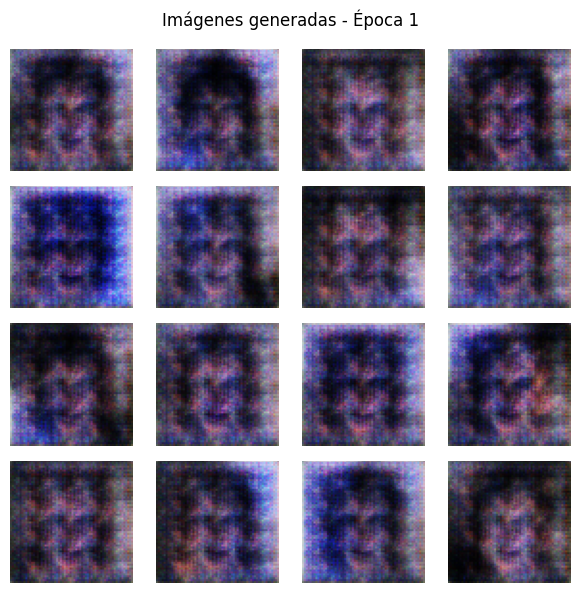

Época 002/30 | D Loss: 0.4961 | G Loss: 1.9175 | D Acc: 0.8015 | Tiempo: 49.6 s


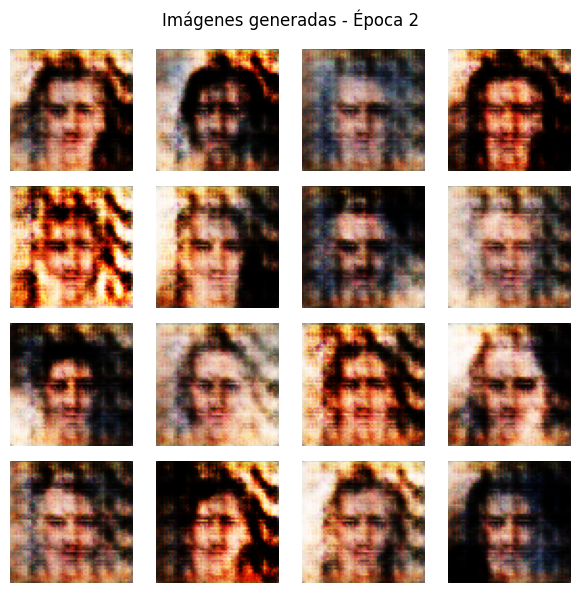

Época 003/30 | D Loss: 0.5040 | G Loss: 1.7654 | D Acc: 0.7889 | Tiempo: 49.0 s


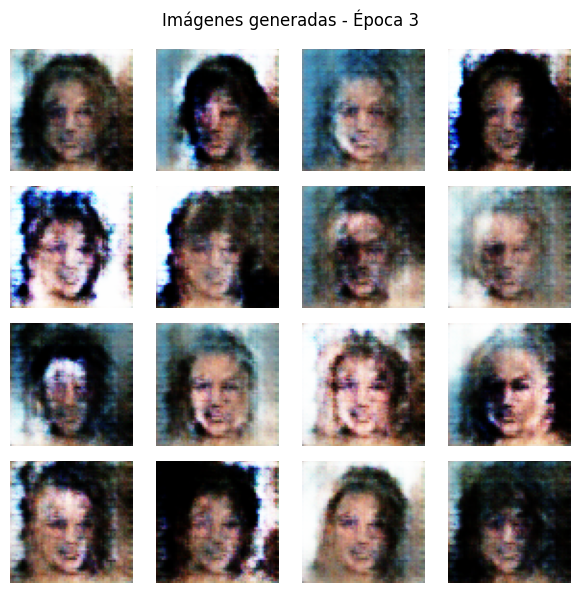

In [ ]:
def train(dataset, epochs):
    """
    Entrena la DCGAN durante un número definido de épocas.
    
    Guarda:
    - Imágenes generadas por época.
    - Checkpoints.
    - Historial de pérdidas.
    """
    history = {
        "epoch": [],
        "d_loss": [],
        "g_loss": [],
        "d_acc": [],
        "epoch_time_sec": []
    }
    
    # Imagen inicial antes de entrenar
    generate_and_save_images(generator, 0, FIXED_NOISE)
    
    for epoch in range(1, epochs + 1):
        start = time.time()
        
        d_losses = []
        g_losses = []
        d_accs = []
        
        for real_batch in dataset:
            d_loss, g_loss, d_acc = train_step(real_batch)
            
            d_losses.append(float(d_loss))
            g_losses.append(float(g_loss))
            d_accs.append(float(d_acc))
        
        epoch_time = time.time() - start
        
        d_mean = np.mean(d_losses)
        g_mean = np.mean(g_losses)
        d_acc_mean = np.mean(d_accs)
        
        history["epoch"].append(epoch)
        history["d_loss"].append(d_mean)
        history["g_loss"].append(g_mean)
        history["d_acc"].append(d_acc_mean)
        history["epoch_time_sec"].append(epoch_time)
        
        print(
            f"Época {epoch:03d}/{epochs} | "
            f"D Loss: {d_mean:.4f} | "
            f"G Loss: {g_mean:.4f} | "
            f"D Acc: {d_acc_mean:.4f} | "
            f"Tiempo: {epoch_time:.1f} s"
        )
        
        # Guardar imágenes por época
        generate_and_save_images(generator, epoch, FIXED_NOISE)
        
        # Guardar checkpoint cada 5 épocas y al final
        if epoch % 5 == 0 or epoch == epochs:
            checkpoint_manager.save()
            
        # Guardar CSV parcial en cada época
        pd.DataFrame(history).to_csv(RESULTS_DIR / "training_history.csv", index=False)
    
    return pd.DataFrame(history)


history_df = train(train_dataset, EPOCHS)
history_df.head()